# **Today you will be working wtih DESI data to calculate different galaxy properties.**

### You will learn how to write equations in python and make plots. By the end of this notebook you should have calculated the star formation rates for your sample and investigated any trends.

### Python is a versatile programming language that is widely used for mathematical calculations. Here's a step-by-step guide to performing mathematical operations in Python:

## 1. Basic Arithmetic Operations

### Python supports basic arithmetic operations out of the box. You can perform addition, subtraction, multiplication, division, and more using standard operators.



In [5]:
# addition is +
result = 2 + 3
print(result)  

5


In [6]:
# subtraction is -
result = 7 - 2
print(result)


5


In [7]:
# multiplication is *
result = 4 * 3
print(result)  

12


In [8]:
# division is /

result = 10 / 2
print(result) 

5.0


In [9]:
# exponential or power is **

result = 2 ** 3
print(result)  

8


## 2. Using the math Module

### For more advanced mathematical functions, Python provides the math module.

In [11]:
# first import the math module

import math

In [12]:
# square root
result = math.sqrt(16)
print(result)  #

4.0


In [13]:
# trigonometric functions
angle = math.radians(45)  # Convert degrees to radians
result = math.sin(angle)
print(result)  # Output: 0.7071067811865475

0.7071067811865475


In [14]:
# Logarithmic functions

result = math.log(10)  # Natural logarithm
print(result)  # Output: 2.302585092994046

result = math.log10(10)  # Base-10 logarithm
print(result)  # Output: 1.0


2.302585092994046
1.0


## 3. Using the numpy Library
### For more complex mathematical operations and handling large arrays, the numpy library is very useful.

In [16]:
# first import the numpy module we import it as np to make typing it easier

import numpy as np

### What is an Array?
### An array is a data structure that can hold multiple values at once. These values are typically of the same type, such as integers or floats, and are stored in a contiguous block of memory. Arrays are useful because they allow you to manage and manipulate a collection of data items efficiently and in a systematic way.

### Arrays allow you to store multiple values in a single variable, making it easier to manage collections of data. For example, instead of creating separate variables for each student's score, you can store all scores in an array.

In [19]:
array = np.array([1, 2, 3, 4, 5])
print(array)

[1 2 3 4 5]


In [20]:
result = array * 2
print(result) 

[ 2  4  6  8 10]


In [21]:
result = np.sqrt(array)
print(result) 

[1.         1.41421356 1.73205081 2.         2.23606798]


## Python Maths Practice

### Try to write some code to evaluate the answers to the following questions. You might need to use numpy or math for some of them.

### Evaluate:
### $ \left(2^3\right)^2 $

### Evaluate:
### $ 2 \left(3 + \left(4 \times 5\right)\right) $

### Calculate the value of:
### $ \left(3e^2\right) \times \left(\frac{4e^3}{2e}\right) $

### Calculate the value of:
### $ \left(\frac{5 + 3 \times 2}{4} + 1\right)^3 $

# Onto the science!

### The first thing that we need to do is load in all of the modules that we will need for this session.

In [28]:
import fitsio
from astropy.table import Table, unique, vstack, join
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import statistics
import seaborn as sns
import pandas as pd
import datashader as ds
from datashader.mpl_ext import dsshow
%matplotlib inline
from matplotlib.colors import LinearSegmentedColormap
cosmo = FlatLambdaCDM(H0=70 * u.km / u.s / u.Mpc, Tcmb0=2.725 * u.K, Om0=0.3)

In [29]:
# Now we need to load in our data. We specify the filepath where the data is saved and then read it using fitsio.

file_path = '/Users/amara/Documents/PhD/Outreach/In2STEM/low_z_sample.fits'
table = fitsio.read(file_path)

In [30]:
# here we put the data into a table
data = Table(table)

In [31]:
#running this will display a few rows of data and all of the columns. You won't need to use all of the columns
data

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,COEFF,VDISP,AV,LOGMSTAR,SFR,FLUX_SYNTH_G,FLUX_SYNTH_R,FLUX_SYNTH_Z,FLUX_SYNTH_SPECMODEL_G,FLUX_SYNTH_SPECMODEL_R,FLUX_SYNTH_SPECMODEL_Z,ABSMAG00_U,KCORR00_U,ABSMAG00_B,KCORR00_B,ABSMAG00_V,KCORR00_V,ABSMAG01_SDSS_U,KCORR01_SDSS_U,ABSMAG01_SDSS_G,KCORR01_SDSS_G,ABSMAG01_SDSS_R,KCORR01_SDSS_R,ABSMAG01_SDSS_I,KCORR01_SDSS_I,ABSMAG01_SDSS_Z,KCORR01_SDSS_Z,OII_3726_FLUX,OII_3726_FLUX_IVAR,HGAMMA_FLUX,HGAMMA_FLUX_IVAR,HGAMMA_EW,HGAMMA_EW_IVAR,HBETA_FLUX,HBETA_FLUX_IVAR,HBETA_EW,OIII_5007_FLUX,OIII_5007_FLUX_IVAR,HALPHA_FLUX,HALPHA_FLUX_IVAR,HALPHA_EW,NII_6584_FLUX,NII_6584_FLUX_IVAR,RA,DEC,DESI_TARGET,SPECTYPE,PHOTSYS,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_W3,FLUX_W4,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,FLUX_IVAR_W3,FLUX_IVAR_W4,LOGMSTAR_COR,HALPHA_SN,HBETA_SN,OIII_5007_SN,NII_6584_SN,HALPHA_BD,HALPHA_ATTENUATION,HALPHA_LUMINOSITY,SFR_CALCULATED
int64,str7,str6,int32,float64,float32[40],float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,int64,str6,str1,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64
39628082469932000,main,bright,8389,0.17970628549270498,0.0 .. 0.0,251.44305,0.017295312,9.846949,0.9252525,6.5219626,11.04771,16.481941,7.2611156,12.050982,17.326838,-18.78818,-0.7237787,-19.5649,0.0529398,-19.88177,-0.17020322,-18.51445,-0.9975083,-19.483805,-0.02815343,-19.916214,-0.13575876,-20.141472,-0.31504118,-20.3148,-0.14171323,35.815044,0.023377717,5.4237075,0.10555107,1.4197108,1.5044065,31.10149,0.09558853,8.055439,16.035278,0.2278347,109.838036,0.19414848,34.32717,35.870987,0.38084945,227.45180044085478,12.301675212133732,1152921504606846976,GALAXY,S,4.688574,8.002625,12.016224,17.266682,28.393185,41.21263,33.262505,24.875086,143.07707,60.52658,51.202255,29.68429,7.2877736,2.8050973,0.73539126,0.0018687149,2.4533685e-05,9.856752,48.39715,9.61577,7.6539645,22.137062,3.5316005,0.43210164,1.4812641764302834e+41,0.8146952970366559
39628365635782848,main,bright,747,0.18146270179611884,0.0031548478 .. 0.0,320.45227,0.31452328,10.281093,0.9462828,8.337335,15.205624,26.071665,10.5946455,18.55449,29.197004,-19.55939,-0.633485,-20.250828,0.057953186,-20.647066,-0.1815969,-19.302898,-0.88997567,-20.161837,-0.031037143,-20.669998,-0.15866452,-21.009344,-0.2865951,-21.164911,-0.13102822,16.73745,0.03541587,10.824218,0.13080138,1.7638751,4.6698136,29.590271,0.14742352,6.1199636,9.971298,0.21915564,127.31419,0.30604506,26.463366,52.493557,0.49902195,29.571600168112756,24.777415124793045,1152921504606846976,GALAXY,S,4.57279,8.961757,14.919879,31.639452,56.825596,87.38857,75.00375,61.42899,364.56174,618.0999,177.08589,54.828068,23.933123,1.6669358,0.474947,0.0013644033,1.993306e-05,10.290896,70.43192,11.361413,4.6679697,37.08223,4.3025694,0.8366125,2.546382914879846e+41,1.4005106031839154
39627636594443093,main,bright,26829,0.052436277760482576,5.5617293e-05 .. 0.0,125.0,0.0,8.245755,0.016682163,8.991959,11.746863,13.996338,10.391372,12.552148,15.345139,-15.799587,-0.7144746,-16.414494,-0.09956819,-16.609901,-0.13800423,-15.574349,-0.9397129,-16.342688,-0.17137459,-16.615782,-0.13212387,-16.755589,0.0076822788,-16.794802,-0.09613618,41.69399,0.03071172,9.859316,0.0934002,1.6714287,3.0910256,36.94545,0.11229702,8.235678,75.00175,0.07533968,99.554855,0.197815,32.52501,6.135296,0.7534488,158.41401422674383,-6.259536139927663,1152921504606846976,GALAXY,S,5.1364675,6.6244044,7.830132,15.110151,18.741573,21.380573,10.426177,7.4375353,116.65225,-1035.4423,456.8549,140.49559,35.79222,2.6716259,0.59764

In [32]:
# you can select a single column by write data['column_name'] as shown below:

data['HALPHA_FLUX']

# This is useful for performing the same calculation on every galaxy in the sample so that you don't have to do it 500,000 times!

109.838036
127.31419
99.554855
65.804184
214.7023
83.46772
98.75185
39.735367
132.53607
...
118.76326


#### For our calculations we will mainly be looking at two emission lines: H$\alpha$ and H$\beta$ they are wavelengths of light that are the result of different paths of de-excitation. We use the flux measurements for our calculations. Flux is a measure of the power of light produced by a light source.

#### Light from galaxies is reduced because of the dust in the galaxies. We call this attenuation. This is what we will calculate now. Code the calculation below to work out the attenuation of H$\alpha$.

#### Now calculating the dust attenuation of the Hα emission , A(Hα), using equation:

$$ A(H\alpha )[mag] = \frac{2.5log(\frac{1}{2.86}\ \times \frac{F_{H\alpha }}{F_{H\beta }})}{\frac{k(H\beta )}{k(H\alpha )}-1} $$

Where $k(H\beta)/k(H\alpha)$ = 1.53 from Calzetti et al. (2000).

$\frac{F_{H\alpha }}{F_{H\beta }}$ is also called the Balmber decrement and is saved in the table as 'HALPHA_BD' so you can put it into the equation as data['HALPHA_BD']

In [35]:
# here we name the variable H alpha attenuation and perform the calculation 
h_alpha_attenuation =  (2.5 * np.log10 ( (1/2.86) * data['HALPHA_BD']) / (1.53 - 1) )   #add your equation here. Be careful of brackets.

In [36]:
#here we add another column to the table and add the values just calculated to it

data['HALPHA_ATTENUATION'] = h_alpha_attenuation

In [37]:
np.max( h_alpha_attenuation)

3.749526

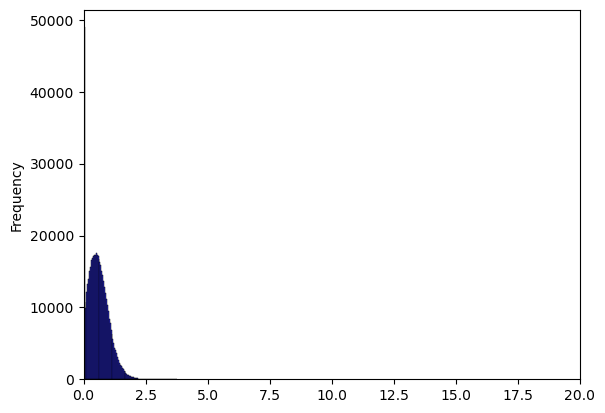

In [38]:
sns.histplot(h_alpha_attenuation, bins=100, color='blue', edgecolor='black')

# Add labels and title
plt.ylabel('Frequency')
plt.xlim(0,20)

# Show the plot
plt.show()

### Before the luminosity attenuation can be calculated the observed luminosity must be calculated using redshift

$$ Luminosity =  4 \times \pi \times (\text{luminosity distance})^2 \times \text{H$\alpha$\:flux} $$

In [40]:
#calculating the luminosity distance in units of centimetres
dlum = cosmo.luminosity_distance(data['Z']).to(u.cm)

#write an equation to calculate luminosity, remember how you have defined your variables. It can be easier to give arrays variable names
# instead of calling the table each time. For example:

h_alpha_flux = data['HALPHA_FLUX'] #remember we want to use our corrrected value for H alpha flux

#converting to correct units of ergs/cm^2/s

h_alpha_flux = h_alpha_flux * (1 * 10**-17)

# now we can use "ha_flux" in the equation.

luminosity =  4 * np.pi * ((dlum)**2) * h_alpha_flux

In [41]:
np.max(luminosity)

<Quantity 1.09953574e+43 cm2>

#### Now calculating the attenuation corrected luminosity using: 

$$ L(H\alpha )_{corr}= L(H\alpha )_{obs} \times 10^{0.4A(H\alpha )} $$

In [43]:
# calculate the corrected luminosity
luminosity_corrected = luminosity * (10**(0.4 * h_alpha_attenuation ))

#add it to the table

data['HALPHA_LUMINOSITY'] = luminosity_corrected

In [44]:
np.max(luminosity_corrected)

<Quantity 6.03225251e+43 cm2>

### Now that we have the corrected luminosity we can calculate the star formation rates of all galaxies.
#### Now the star formation rate can be calculated using: 

$$ SFR[M_{\odot}yr^{-1}] = (5.5 \times 10^{-42} )\times L(H\alpha )_{corr} $$

In [46]:
#calculate star formation rates

sfr = (5.5 * 10**(-42)) * data['HALPHA_LUMINOSITY']

# add star formation rates to table 

data['SFR_CALCULATED'] = sfr

In [47]:
sfr

0.8146952970366559
1.4005106031839154
0.035728398650479005
2.210115583818458
1.0592526966293165
0.8760237059769445
0.5178349786844962
0.12894191975082792
3.3312680394701997
...
0.8347549025782705


#### Now we will plot a histogram to show the distribution of our star formation rates.

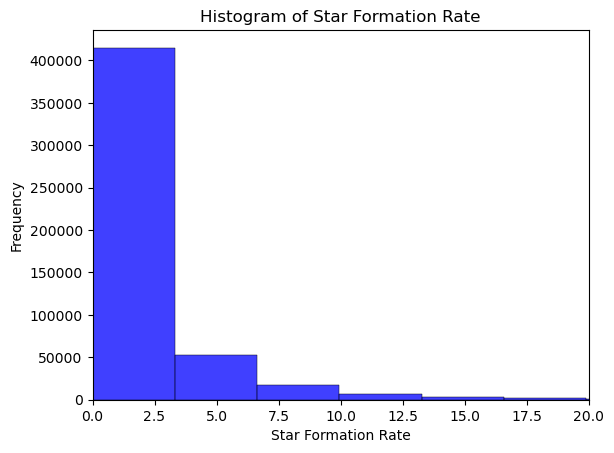

In [49]:
sns.histplot(data['SFR_CALCULATED'], bins=100, color='blue', edgecolor='black')

# Add labels and title
plt.xlabel('Star Formation Rate')
plt.ylabel('Frequency')
plt.xlim(0,20)
plt.title('Histogram of Star Formation Rate')

# Show the plot
plt.show()

### Questions to think about

### 1. What sort of values do we get for star formation rate? 
### 2. What do the units of star formation rate mean?
### 3. Can you calculate some statistics of the star formation rate, such as the mean and median? Google how to use numpy to do this

In [51]:
# calculations on star formation rate:

mean_sfr = np.mean(sfr)
median_sfr = np.median(sfr)

### The next cell will plot the star formation rate distribution with redshift. It will be colour coded by galaxy mass. What trends can you see?

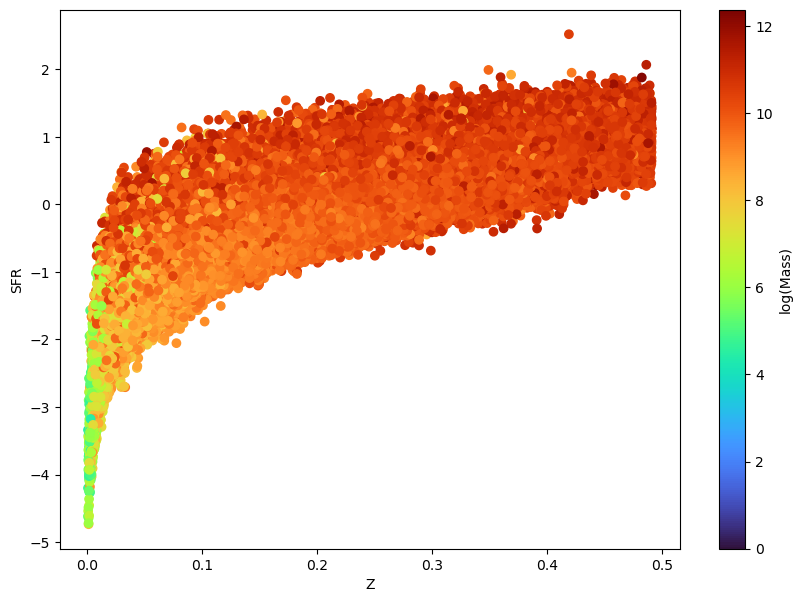

In [53]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    x=data['Z'],
    y=np.log10(sfr),
    c=data['LOGMSTAR'],
    cmap='turbo'
)

ax.set_xlabel('Z')
ax.set_ylabel('SFR')

plt.colorbar(scatter, label = 'log(Mass)',ax=ax)
plt.show()


### Now you will see how star formation rate trends with different quantities. The code cell below has the very basic outline for some code to plot different variable against each other, try plotting different quantities in the table against each other to see how they are correlated.

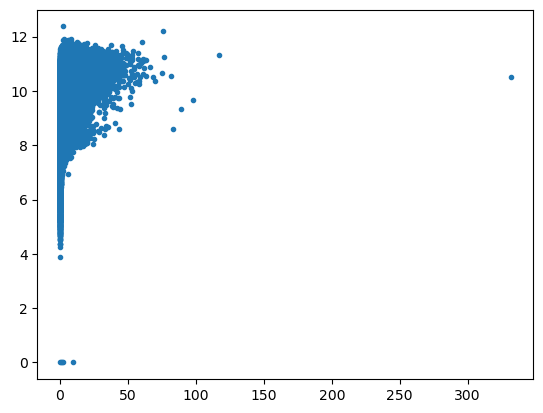

In [55]:
#change x and y to variables that you want to investigate. You might have to change the axes limits for it to make sense.
# remove the # to make the other lines active and add axes labels etc.

x = sfr
y = data['LOGMSTAR']

plt.plot(x, y , '.')
#plt.xlim(,)
#plt.ylim(,)
#plt.xlabel('')
#plt.ylabel('')

plt.show()